In [1]:
import pyautogui
import win32gui
import win32con
import schedule
import time
import random
import math
import numpy as np
import matplotlib.pyplot as plt
from PIL import ImageGrab,Image

In [2]:
fish_width_start = 380
fish_width_end = 440
fish_height_start = 100
fish_height_end = 180

window_width = 800
window_height = 600

hwnd_list = []
def get_hwnd(hwnd, extra):
    title = win32gui.GetWindowText(hwnd)
    if ("幻唐志" in title) and ("RENDER" not in title):
        hwnd_list.append(hwnd)

def get_client_rect(hwnd):
    """
    获取窗口客户区的桌面坐标，不包括标题栏和边框
    返回: (left, top, right, bottom)
    """
    left, top = win32gui.ClientToScreen(hwnd, (0, 0))
    rect = win32gui.GetClientRect(hwnd)
    right = left + rect[2]
    bottom = top + rect[3]
    return left, top, right, bottom

def human_delay(base_seconds: float, sigma: float = 0.3) -> float:
    """模拟人类操作延迟，base_seconds 为中位数"""
    return max(0.05, random.lognormvariate(math.log(base_seconds), sigma))

win32gui.EnumWindows(get_hwnd, None)
assert len(hwnd_list) , "钓鱼只支持1个窗口"

hwnd = hwnd_list[0]
# win32gui.ShowWindow(hwnd, win32con.SW_RESTORE)
# win32gui.SetForegroundWindow(hwnd)

# left, top, right, bottom = get_client_rect(hwnd)
# time.sleep(human_delay(1))

# print(left, top, right, bottom)
# # game_image = ImageGrab.grab(bbox=(left,top , left + window_width , top + window_height))
# game_image = ImageGrab.grab(bbox=(left+fish_width_start,top + fish_height_start, left+fish_width_end, top+fish_height_end))

# plt.imshow(game_image)
# plt.show()

In [49]:
has_fish = True

while has_fish:
    # game_image = ImageGrab.grab(bbox=(left+fish_width_start,top + fish_height_start, left+fish_width_end, top+fish_height_end))
    game_image = Image.open(r"C:\Users\27321\Desktop\1.png")
    try:
        start_fight_location = pyautogui.locate(str(r"C:\Users\27321\shenwu\resource\Fish\you_yu.png"),game_image, grayscale=True,confidence=0.7)
        abs_x = left + start_fight_location.left + start_fight_location.width // 2
        abs_y = top + start_fight_location.top + start_fight_location.height // 2

        pyautogui.moveTo(abs_x,abs_y, duration=human_delay(0.2))
        pyautogui.click()
        time.sleep(human_delay(1))
        has_fish = False

    except Exception as e:
        print(f"还未钓到鱼 {e}")
        time.sleep(human_delay(0.2))

In [ ]:
game_image = Image.open(r"C:\Users\27321\Desktop\1.png")
image_array = np.array(game_image)
game_image = Image.fromarray(image_array[100:300,300:500,:])
start_fight_location = pyautogui.locate(str(r"C:\Users\27321\shenwu\resource\Fish\you_yu.png"),game_image, grayscale=True,confidence=0.5)
abs_x = left + start_fight_location.left + start_fight_location.width // 2
abs_y = top + start_fight_location.top + start_fight_location.height // 2

In [31]:
image_array = np.array(game_image)
image_array.shape

(600, 1155, 3)

In [ ]:
plt.imshow(image_array[100:200,300:500,:])
plt.show()

In [5]:
from rapidocr_onnxruntime import RapidOCR

engine = RapidOCR()
result, _ = engine(r"C:\Users\27321\Desktop\shenwu\ScreenShot_2026-09-17_090935_391.png")

# ✅ 精确查找
target = "雪舞"
found = [(box, text, score) for box, text, score in result if target in text]

# # ✅ 正则匹配（处理数字、变量文本）
# import re
# pattern = r"金币[:\s]*(\d+)"
# for box, text, score in result:
#     match = re.search(pattern, text)
#     if match:
#         print(f"找到金币: {match.group(1)}, 位置: {box}")

In [8]:
found[0][0]

[[500.0, 362.0], [537.0, 365.0], [535.0, 383.0], [499.0, 380.0]]

In [56]:
xun_you_height_start = 270
xun_you_height_end = 460

window_width = 800
window_height = 600

hwnd_list = []
def get_hwnd(hwnd, extra):
    title = win32gui.GetWindowText(hwnd)
    if ("幻唐志" in title) and ("RENDER" not in title):
        hwnd_list.append(hwnd)

def get_client_rect(hwnd):
    """
    获取窗口客户区的桌面坐标，不包括标题栏和边框
    返回: (left, top, right, bottom)
    """
    left, top = win32gui.ClientToScreen(hwnd, (0, 0))
    rect = win32gui.GetClientRect(hwnd)
    right = left + rect[2]
    bottom = top + rect[3]
    return left, top, right, bottom

def human_delay(base_seconds: float, sigma: float = 0.3) -> float:
    """模拟人类操作延迟，base_seconds 为中位数"""
    return max(0.05, random.lognormvariate(math.log(base_seconds), sigma))

win32gui.EnumWindows(get_hwnd, None)
assert len(hwnd_list) , "钓鱼只支持1个窗口"

hwnd = hwnd_list[0]
win32gui.ShowWindow(hwnd, win32con.SW_HIDE)
win32gui.SetForegroundWindow(hwnd)

left, top, right, bottom = get_client_rect(hwnd)
time.sleep(human_delay(1))
win32gui.ShowWindow(hwnd, win32con.SW_SHOWNORMAL)

# game_image = ImageGrab.grab(bbox=(left,top , left+window_width, top+window_height))
# game_image = ImageGrab.grab(bbox=(left,top + xun_you_height_start, left+window_width, top+xun_you_height_end))

# plt.imshow(game_image)
# plt.show()

0

In [17]:
from rapidocr_onnxruntime import RapidOCR

engine = RapidOCR()
result, _ = engine(game_image)

# ✅ 精确查找
target = "开始战斗"
found = [(box, text, score) for box, text, score in result if target in text]

In [ ]:
import matplotlib.pyplot as plt
import matplotlib.patches as patches
import numpy as np

# RapidOCR 返回结果
ocr_result = [
    ([[285.0, 356.0], [346.0, 356.0], [346.0, 376.0], [285.0, 376.0]],
     '开始战斗',
     0.9998622536659241)
]

# ========== 如果有原始游戏截图，取消下面的注释 ==========
# img = plt.imread("game_screenshot.png")
fig, ax = plt.subplots(1, figsize=(12, 8))
ax.imshow(game_image)
# ========================================================

# 没有图片时用空白画布演示
# fig, ax = plt.subplots(1, figsize=(10, 8))
ax.set_xlim(0, 500)
ax.set_ylim(0, 500)
ax.invert_yaxis()  # ⚠️ 关键：图像坐标系y轴向下，matplotlib默认向上
ax.set_aspect('equal')
ax.grid(True, alpha=0.3)

for bbox, text, confidence in ocr_result:
    bbox = np.array(bbox)

    # 计算中心点
    center_x = np.mean(bbox[:, 0])
    center_y = np.mean(bbox[:, 1])

    # 绘制bbox矩形
    rect = patches.Polygon(bbox, linewidth=2, edgecolor='lime',
                           facecolor='lime', alpha=0.15, closed=True)
    ax.add_patch(rect)

    # 绘制中心点
    ax.plot(center_x, center_y, 'r+', markersize=15, markeredgewidth=2,
            label=f'Center ({center_x:.1f}, {center_y:.1f})')

    # 标注文字和置信度
    ax.text(center_x, center_y - 15, f'{text}\n{confidence:.4f}',
            ha='center', va='bottom', fontsize=10, color='white',
            bbox=dict(boxstyle='round,pad=0.3', facecolor='black', alpha=0.7))

    print(f"文本: {text}")
    print(f"置信度: {confidence:.4f}")
    print(f"BBox顶点: {bbox.tolist()}")
    print(f"中心点: ({center_x:.1f}, {center_y:.1f})")
    print("-" * 40)

ax.set_title("RapidOCR BBox & Center Point Visualization", fontsize=14)
ax.legend(loc='upper right')
plt.tight_layout()
plt.show()

# 任务

In [ ]:
window_width = 800
window_height = 600

hwnd_list = []
def get_hwnd(hwnd, extra):
    title = win32gui.GetWindowText(hwnd)
    if ("幻唐志" in title) and ("RENDER" not in title):
        hwnd_list.append(hwnd)

def get_client_rect(hwnd):
    """
    获取窗口客户区的桌面坐标，不包括标题栏和边框
    返回: (left, top, right, bottom)
    """
    left, top = win32gui.ClientToScreen(hwnd, (0, 0))
    rect = win32gui.GetClientRect(hwnd)
    right = left + rect[2]
    bottom = top + rect[3]
    return left, top, right, bottom

def human_delay(base_seconds: float, sigma: float = 0.3) -> float:
    """模拟人类操作延迟，base_seconds 为中位数"""
    return max(0.05, random.lognormvariate(math.log(base_seconds), sigma))

win32gui.EnumWindows(get_hwnd, None)
assert len(hwnd_list) , "钓鱼只支持1个窗口"

hwnd = hwnd_list[0]
win32gui.ShowWindow(hwnd, win32con.SW_HIDE)
win32gui.SetForegroundWindow(hwnd)

left, top, right, bottom = get_client_rect(hwnd)
time.sleep(human_delay(1))
win32gui.ShowWindow(hwnd, win32con.SW_SHOWNORMAL)

game_image = ImageGrab.grab(bbox=(left,top , left+window_width, top+window_height))

plt.imshow(game_image)
plt.show()

In [5]:
from rapidocr_onnxruntime import RapidOCR

engine = RapidOCR()
result, _ = engine(r"C:\Users\27321\Desktop\Snipaste_2026-09-24_13-43-12.png")

# ✅ 精确查找
target = "开始战斗"
found = [(box, text, score) for box, text, score in result if target in text]
found

[([[427.0, 596.0], [516.0, 594.0], [517.0, 621.0], [427.0, 624.0]],
  '开始战斗',
  0.9998034536838531)]

正在加载 OCR 模型...
正在检测图像: C:\Users\27321\Desktop\2.png
共检测到 73 个文本区域。


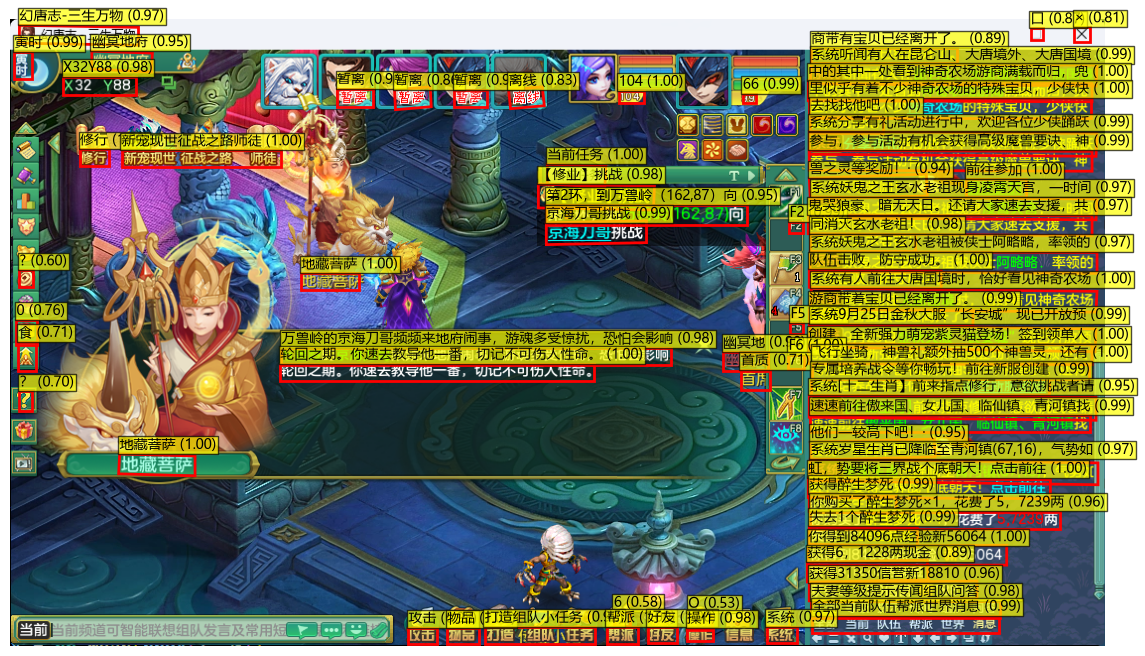

In [13]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.patches import Polygon
from PIL import Image
from rapidocr_onnxruntime import RapidOCR

# 设置中文字体（Windows 常用 Microsoft YaHei 或 SimHei）
plt.rcParams['font.sans-serif'] = ['Microsoft YaHei', 'SimHei', 'SimSun'] 
# 解决坐标轴负号 '-' 显示为方块的问题
plt.rcParams['axes.unicode_minus'] = False 

def visualize_ocr(image_path):
    # 1. 初始化 RapidOCR 引擎
    print("正在加载 OCR 模型...")
    ocr = RapidOCR()
    
    # 2. 执行 OCR 检测
    print(f"正在检测图像: {image_path}")
    result, elapse = ocr(image_path)
    
    # 3. 使用 PIL 读取图像并转换为 numpy 数组，用于 matplotlib 展示
    img = Image.open(image_path)
    img_array = np.array(img)
    
    # 4. 创建 matplotlib 画布
    fig, ax = plt.subplots(1, 1, figsize=(12, 10))
    ax.imshow(img_array)
    
    # 5. 遍历检测结果并绘制 bbox 和文本
    if result:
        print(f"共检测到 {len(result)} 个文本区域。")
        for line in result:
            bbox = np.array(line[0])  # 边界框坐标 [[x1, y1], [x2, y2], [x3, y3], [x4, y4]]
            text = line[1]            # 识别出的文本
            score = line[2]           # 置信度
            
            # 使用 matplotlib.patches.Polygon 绘制四边形框
            # 因为 OCR 检测出的框可能是倾斜的，所以用多边形比矩形更准确
            polygon = Polygon(
                bbox, 
                closed=True, 
                edgecolor='red',     # 框的颜色
                facecolor='none',    # 框内部透明
                linewidth=2
            )
            ax.add_patch(polygon)
            
            # 在框的左上角添加识别出的文本和置信度
            # bbox[0] 是左上角的坐标 (x, y)
            ax.text(
                bbox[0][0], bbox[0][1] - 5, 
                f"{text} ({score:.2f})", 
                bbox={'facecolor': 'yellow', 'alpha': 0.7, 'pad': 1}, # 文本背景色
                fontsize=10,
                color='black'
            )
    else:
        print("未在图像中检测到任何文本。")
            
    # 6. 隐藏坐标轴并显示图像
    ax.set_axis_off()
    plt.tight_layout()
    plt.show()

if __name__ == "__main__":
    # 请将这里的路径替换为你本地图像的实际路径
    # 例如: "C:/images/test.jpg" 或 "./test_image.png"
    IMAGE_PATH = r"C:\Users\27321\Desktop\2.png"
    
    visualize_ocr(IMAGE_PATH)